Loading data...


/var/folders/dt/pqrpvqxj6jnfx7sqqlbyy7_w0000gn/T/ipykernel_8094/1015985625.py:11: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Loaded 9512578 records

Data Overview:
Number of unique origin countries: 227
Number of unique destination countries: 227
Years in dataset: [2020]

1. CONTINENT ANALYSIS

Average Logistics Costs by Origin Continent:
                          mean       median           std    count
origin_continent                                                  
OC                15741.909497  3533.362691  25761.656106   472644
SA                 7388.952009  1464.523880  16075.274820   632092
AF                 6620.271927   677.169645  15120.306588  1621650
AS                 4855.056924   500.987897  12877.569233  2942150
EU                 4278.393479   418.582637  10992.021598  2648258

Average Logistics Costs by Origin-Destination Continent Pairs:
destination_continent            AF            AS            EU            OC  \
origin_continent                                                                
AF                      3351.267197   5726.559903   4447.238059  21188.803163   
AS      

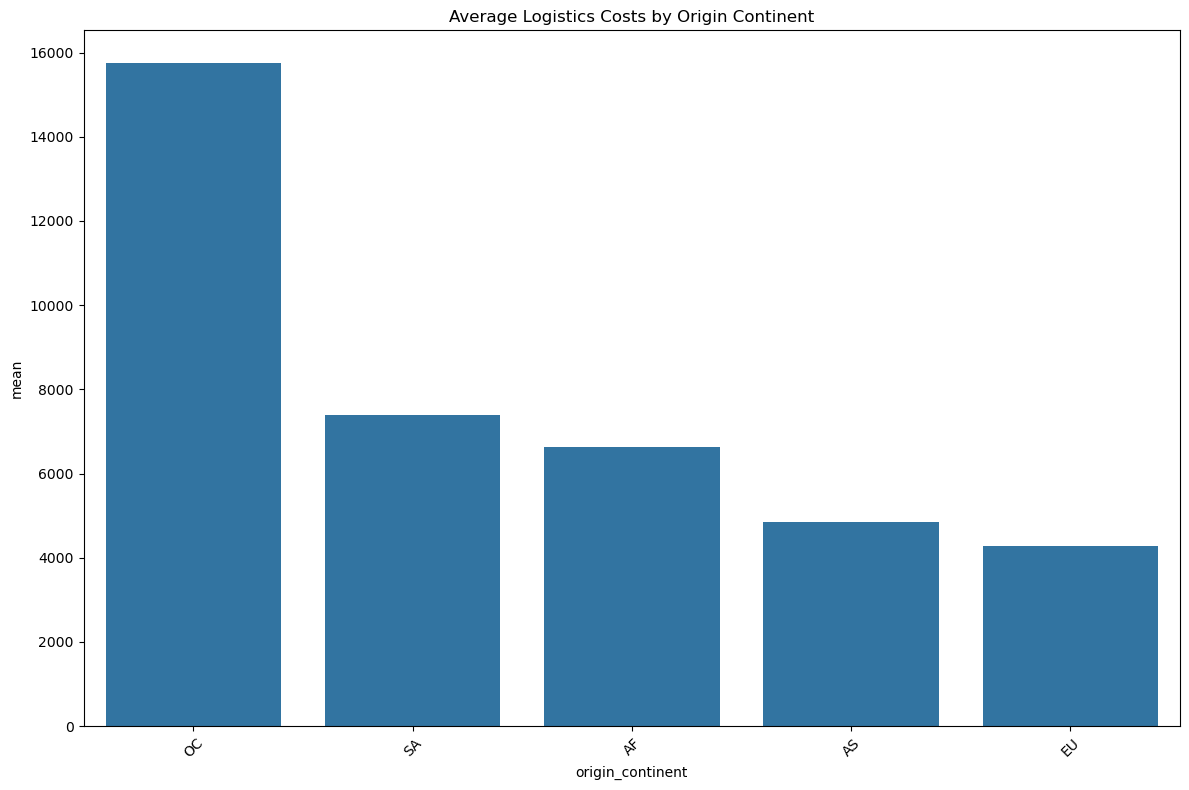

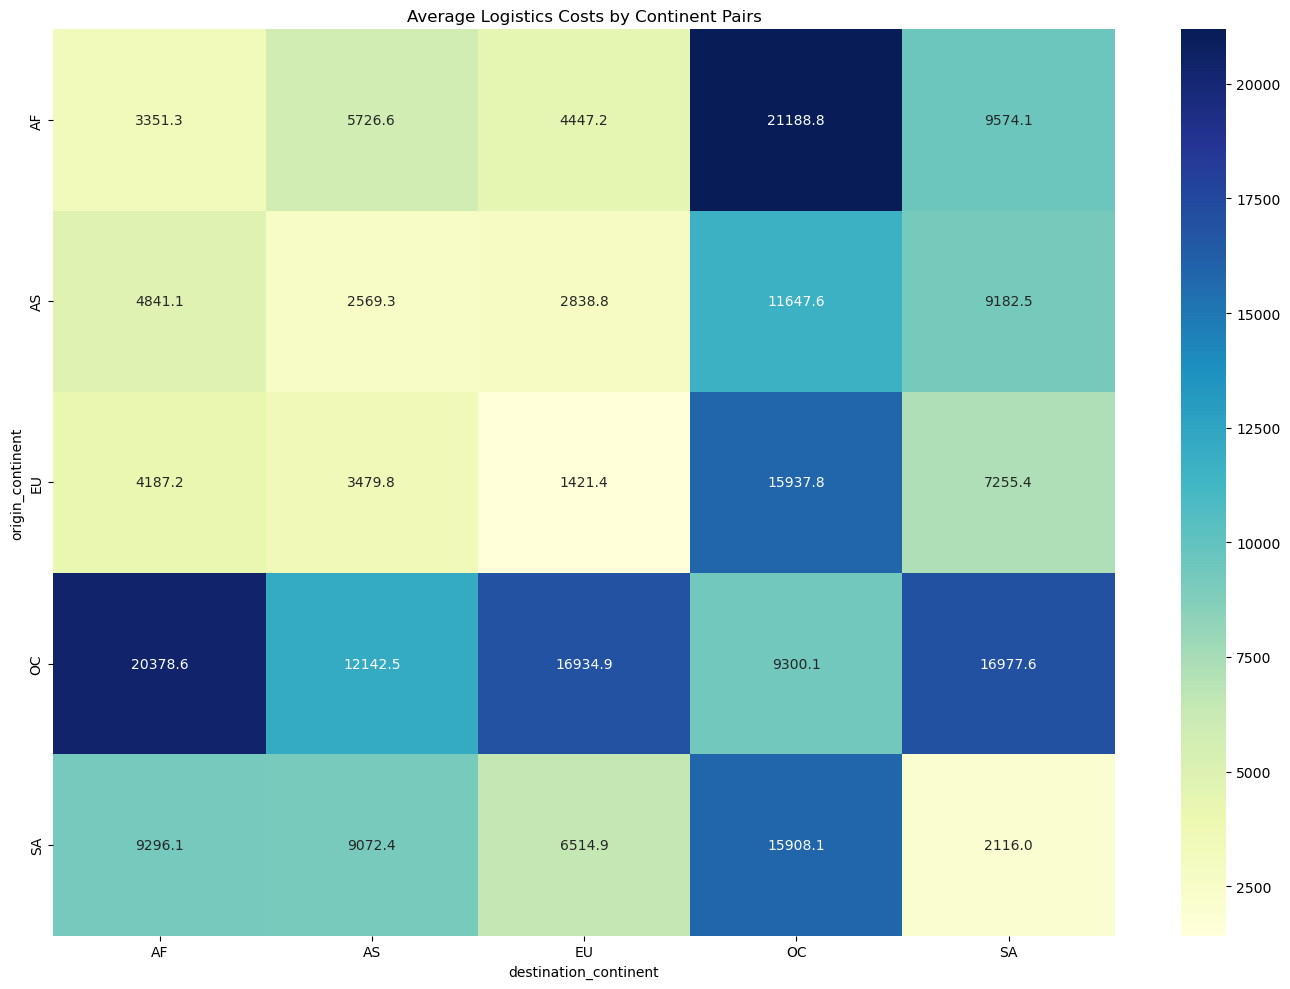

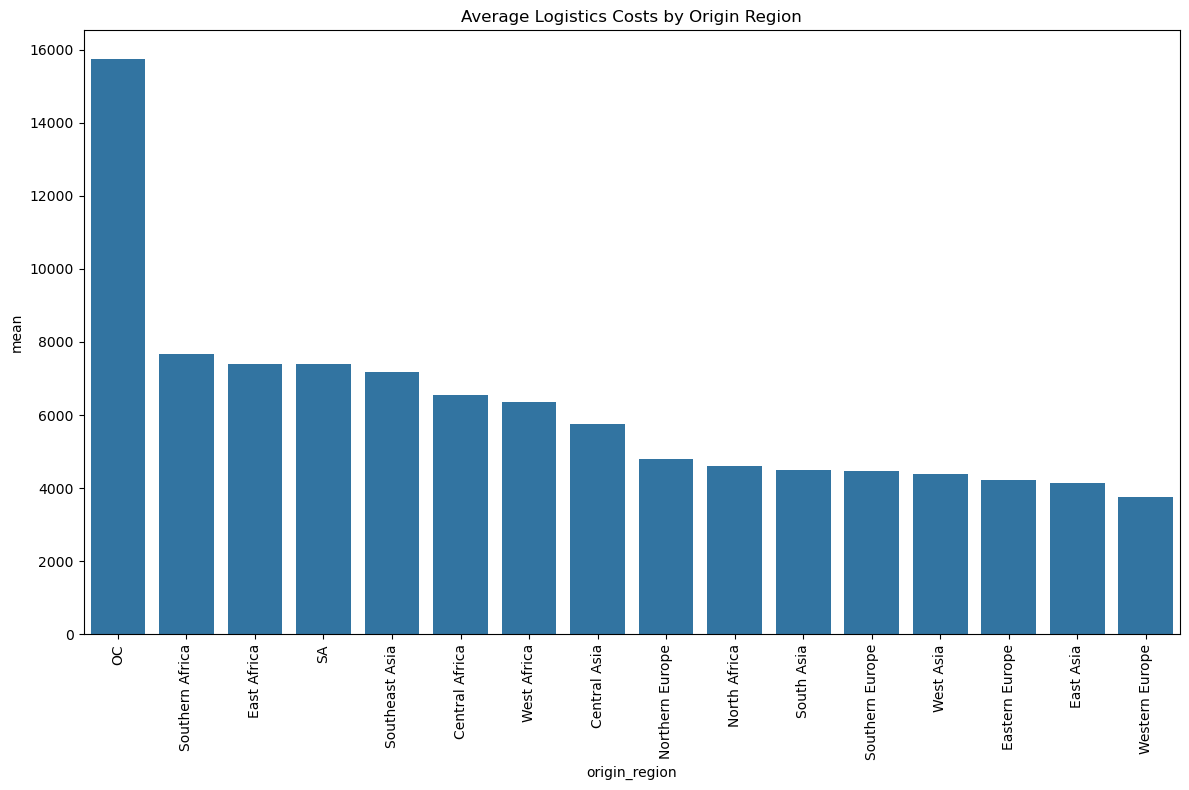

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up paths
data_path = '../data/wb_data_all_fields_final.csv'

print("Loading data...")
df = pd.read_csv(data_path)
print(f"Loaded {len(df)} records")

# Basic info
print("\nData Overview:")
print(f"Number of unique origin countries: {df['origin_ISO'].nunique()}")
print(f"Number of unique destination countries: {df['destination_ISO'].nunique()}")
print(f"Years in dataset: {df['year'].unique()}")

# 1. Analysis by Continent
print("\n1. CONTINENT ANALYSIS")
print("===================")

# Calculate average costs by origin continent
continent_costs = df.groupby('origin_continent')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
continent_costs = continent_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Origin Continent:")
print(continent_costs)

# Continental flow analysis
continent_flow = pd.crosstab(df['origin_continent'], df['destination_continent'], 
                          values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Origin-Destination Continent Pairs:")
print(continent_flow)

# 2. Analysis by Region
print("\n2. REGIONAL ANALYSIS")
print("==================")

# Calculate average costs by origin region
region_costs = df.groupby('origin_region')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
region_costs = region_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Origin Region:")
print(region_costs)

# Regional flow analysis
region_flow = pd.crosstab(df['origin_region'], df['destination_region'], 
                         values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Origin-Destination Region Pairs:")
print(region_flow)

# 3. Analysis by Income Group
print("\n3. INCOME GROUP ANALYSIS")
print("======================")

# Check if there's a separate income group for origin and destination
if 'origin_income_group' in df.columns and 'destination_income_group' in df.columns:
    # Use separate income group columns
    income_origin = 'origin_income_group'
    income_dest = 'destination_income_group'
else:
    # Use the single income_group column
    # Assume this is for the origin country
    income_origin = 'income_group'
    income_dest = 'income_group'

# Calculate average costs by origin income group
income_costs = df.groupby(income_origin)['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
income_costs = income_costs.sort_values('mean', ascending=False)

print(f"\nAverage Logistics Costs by Origin Income Group:")
print(income_costs)

# Income group flow analysis (if applicable)
if income_origin != income_dest:
    income_flow = pd.crosstab(df[income_origin], df[income_dest], 
                            values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
    print("\nAverage Logistics Costs by Origin-Destination Income Group Pairs:")
    print(income_flow)

# Save results to CSV files
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

# continent_costs.to_csv(f"{output_dir}/continent_costs.csv")
# continent_flow.to_csv(f"{output_dir}/continent_flow.csv")
# region_costs.to_csv(f"{output_dir}/region_costs.csv")
# region_flow.to_csv(f"{output_dir}/region_flow.csv")
# income_costs.to_csv(f"{output_dir}/income_costs.csv")
# if income_origin != income_dest:
#     income_flow.to_csv(f"{output_dir}/income_flow.csv")

# print("\nAnalysis complete. Results saved to CSV files in the output directory.")

# Optional: Create visualizations
try:
    plt.figure(figsize=(12, 8))
    sns.barplot(x=continent_costs.index, y=continent_costs['mean'])
    plt.title('Average Logistics Costs by Origin Continent')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_costs.png")
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(continent_flow, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title('Average Logistics Costs by Continent Pairs')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_flow_heatmap.png")
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=region_costs.index, y=region_costs['mean'])
    plt.title('Average Logistics Costs by Origin Region')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/region_costs.png")
    
    print("Visualizations saved to output directory.")
except Exception as e:
    print(f"Error creating visualizations: {e}") 

# Regional Analysis after regrouping the countries

Loading country classification data...
Loaded 227 country classifications
Loading main dataset...


/var/folders/dt/pqrpvqxj6jnfx7sqqlbyy7_w0000gn/T/ipykernel_56474/4156468587.py:20: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, usecols=[


Loaded 9512578 records

Filtering out empty or invalid values...
Original data shape: (9512578, 11)
Filtered data shape: (6635322, 11)
Removed 2877256 records (30.25% of data)

Data Overview:
Number of unique origin countries: 227
Number of unique destination countries: 227
Years in dataset: [2020]

1. CONTINENT ANALYSIS (ORIGINAL)

Average Logistics Costs by Origin Continent:
                         mean       median           std    count
origin_continent                                                 
OC                6131.682864  1266.144491  12710.676085   332054
AF                4601.350694   773.519830  10613.975196  1000723
SA                4249.718273   942.436987  10141.362425   490646
AS                2884.576819   547.785917   6752.556871  2023183
EU                2779.109858   376.041736   6732.567564  1917636

Average Logistics Costs by Origin-Destination Continent Pairs:
destination_continent           AF           AS           EU           OC  \
origin_continent 

/var/folders/dt/pqrpvqxj6jnfx7sqqlbyy7_w0000gn/T/ipykernel_56474/4156468587.py:127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flow_costs = df.groupby('flow_bin')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
/var/folders/dt/pqrpvqxj6jnfx7sqqlbyy7_w0000gn/T/ipykernel_56474/4156468587.py:136: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_flow_costs = df.groupby(['fixed_origin_region', 'flow_bin'])['Unit logistics costs ($/ton)'].agg(['mean', 'count'])



Average Logistics Costs by Flow Volume (tonnes):
                 mean       median           std    count
flow_bin                                                 
0-10      5423.380339  2032.692042  10090.395759  3360458
10-100    2158.156958   311.637614   6459.149261  1388605
100-1000  1245.009149   184.686129   4888.835917  1075629
1K-10K     956.788314   156.563308   3734.145418   610140
10K-100K   780.073190   142.806976   2682.228364   181575
>100K     1090.433978   108.915767   2839.214557    18915

6. FIXED REGION AND FLOW VOLUME ANALYSIS

Top 20 Region-Flow Volume Combinations by Cost:
                                     mean   count
fixed_origin_region flow_bin                     
Oceania             0-10      7190.739125  224519
Africa              0-10      6642.043989  505949
Southeast Asia      0-10      6598.736067  126400
Latin America       0-10      6346.548960  437861
North America       0-10      6192.751446  162661
Unclassified        0-10      5757.395954  29

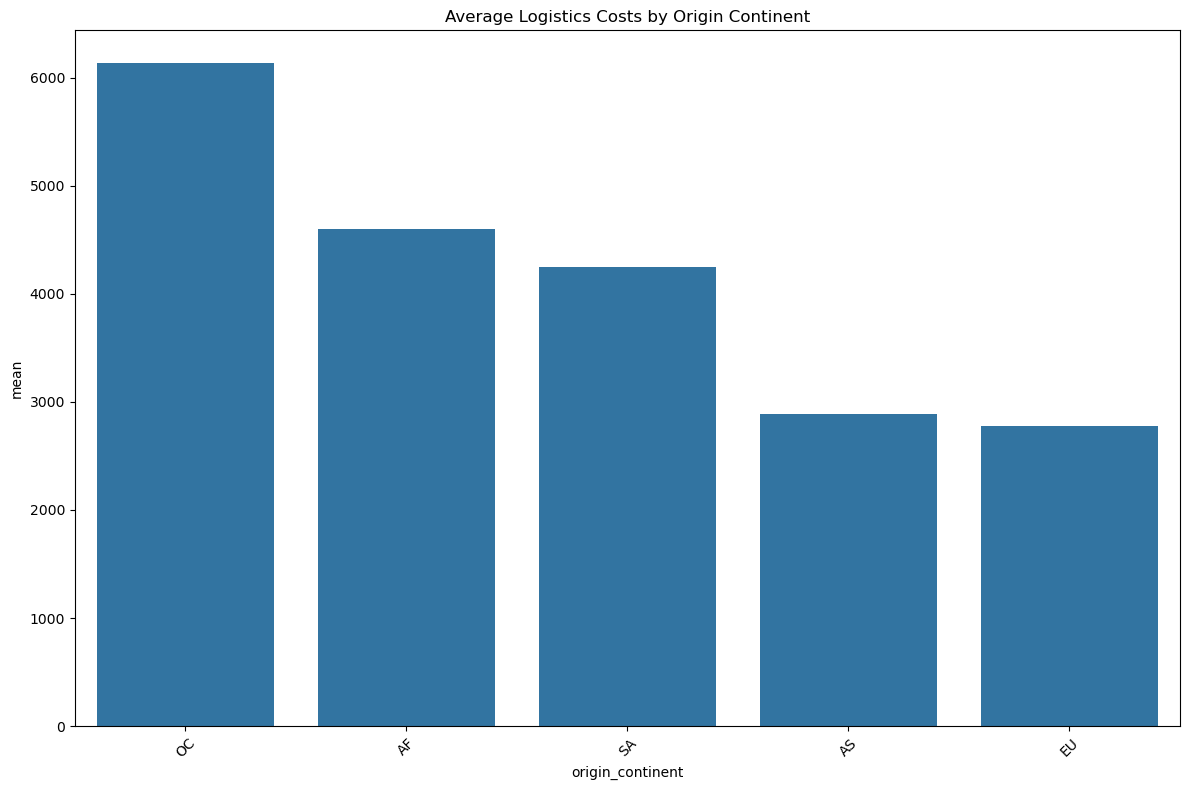

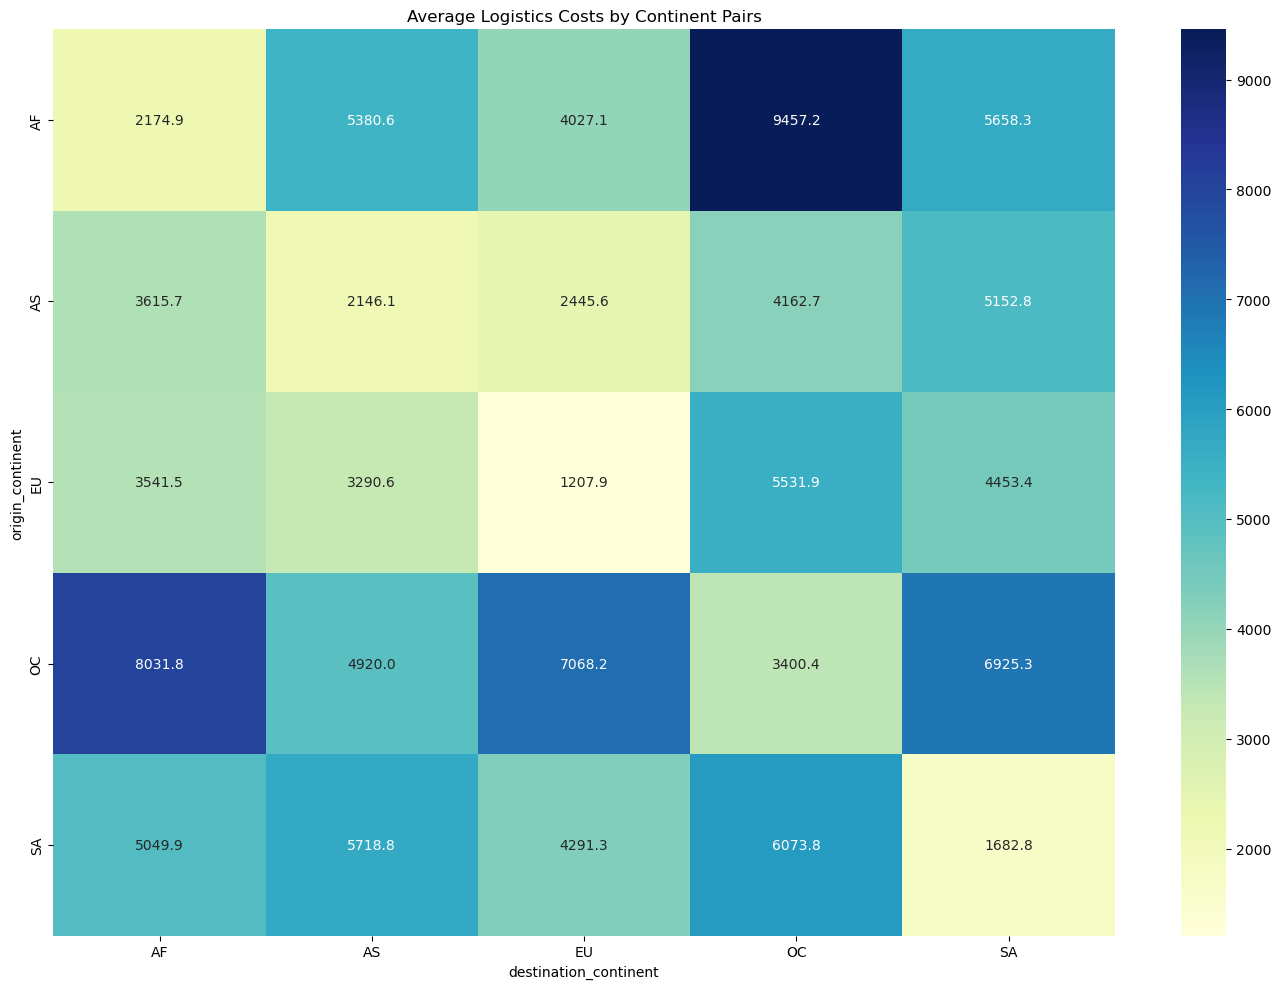

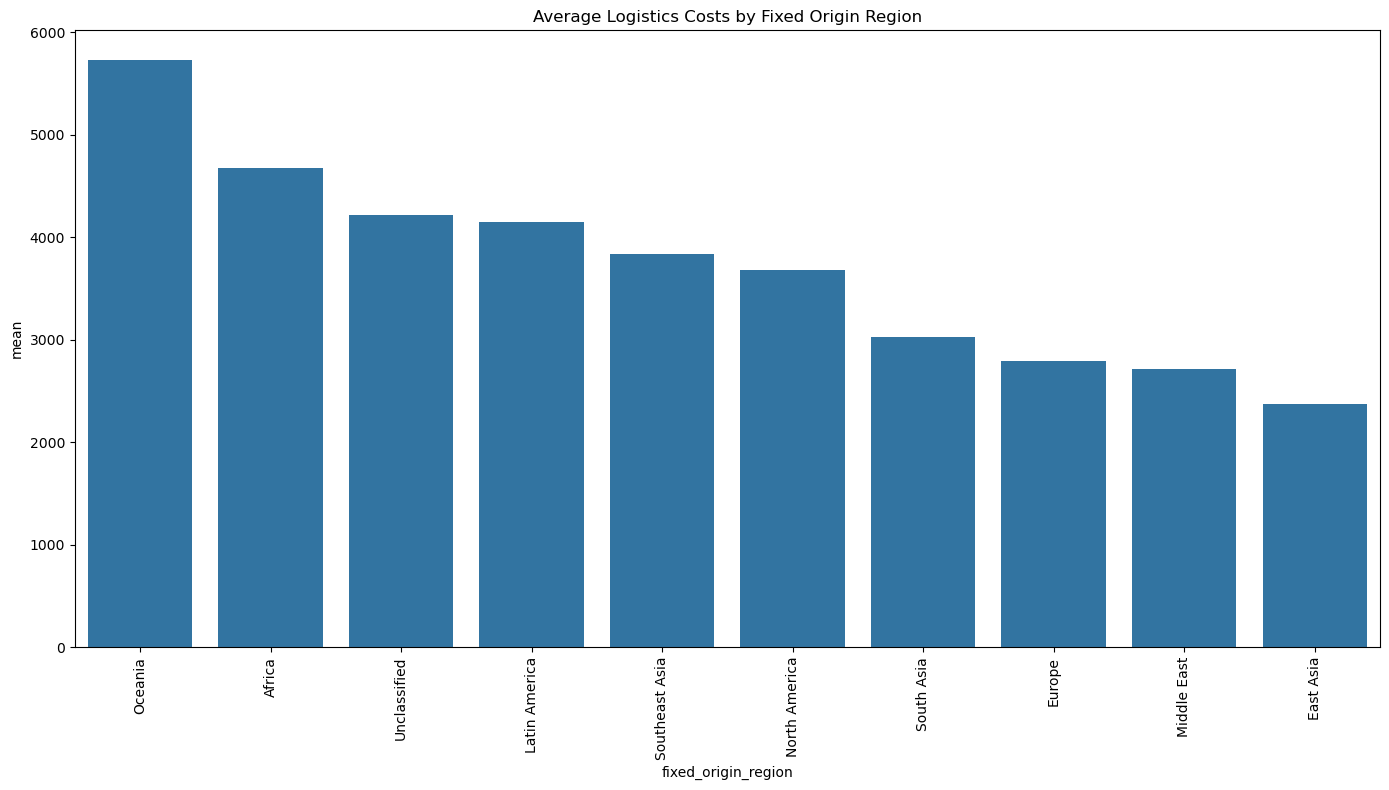

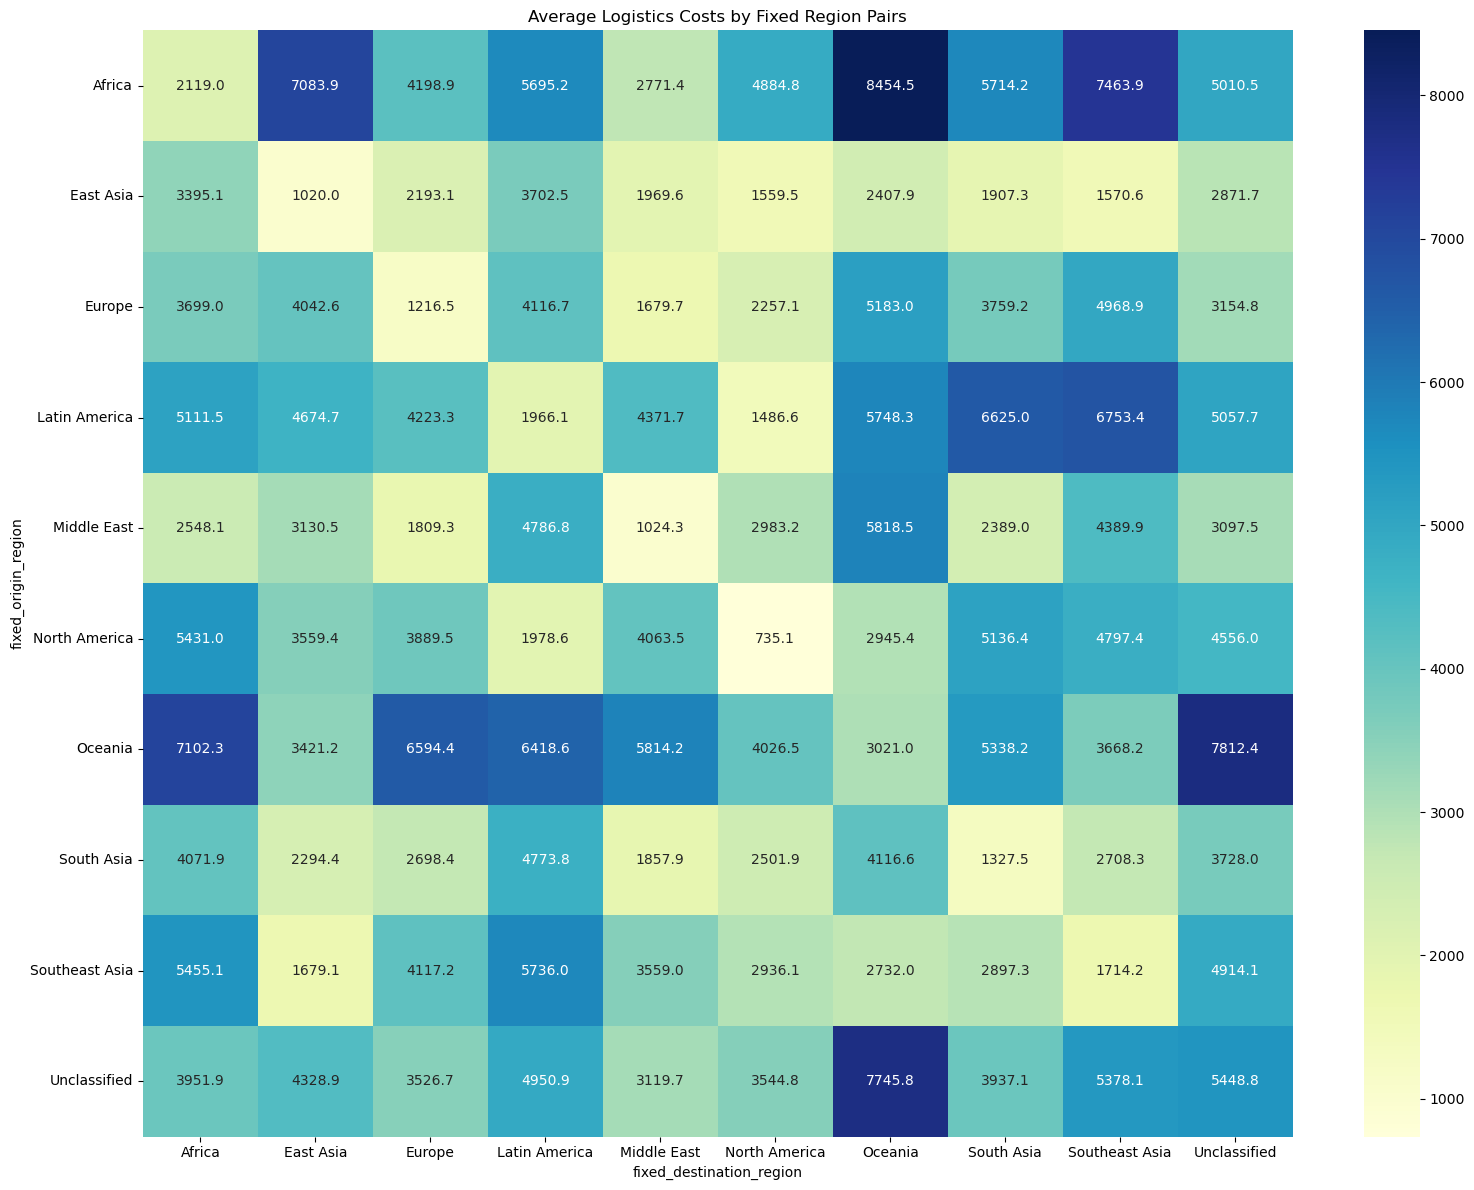

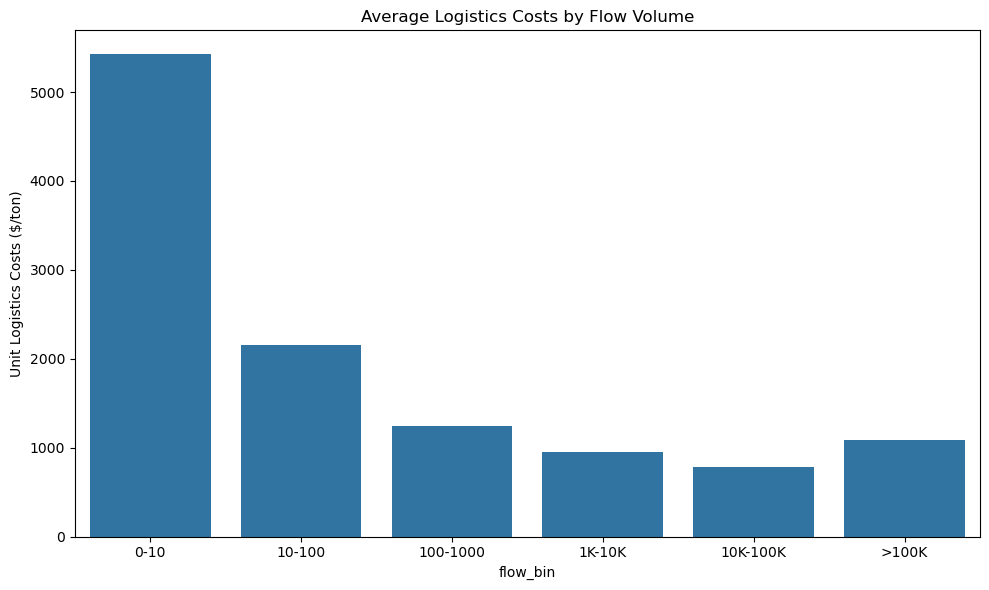

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up paths
data_path = '../data/wb_data_all_fields_final.csv'
region_data_path = '../data/Final_Country_Classification.csv'

print("Loading country classification data...")
region_df = pd.read_csv(region_data_path)
print(f"Loaded {len(region_df)} country classifications")

# Create mapping dictionaries from country code to fixed_region
country_to_region = dict(zip(region_df['country_code'], region_df['fixed_region']))

print("Loading main dataset...")
# Load only necessary columns to save memory with such a large file
df = pd.read_csv(data_path, usecols=[
    'origin_ISO', 'destination_ISO', 'origin_continent', 'destination_continent',
    'origin_region', 'destination_region', 'income_group', 'Unit logistics costs ($/ton)',
    'flow(tonne)', 'distance(km)', 'year'
])
print(f"Loaded {len(df)} records")

# Filter out empty or zero values
print("\nFiltering out empty or invalid values...")
print(f"Original data shape: {df.shape}")
df_filtered = df[
    (df['flow(tonne)'] > 0) &
    # (df['distance(km)'] > 0) &  # Commented out as per user's example
    (df['Unit logistics costs ($/ton)'] > 0)
]
print(f"Filtered data shape: {df_filtered.shape}")
print(f"Removed {len(df) - len(df_filtered)} records ({(len(df) - len(df_filtered)) / len(df) * 100:.2f}% of data)")

# Use the filtered dataframe for analysis
df = df_filtered

# Map countries to their fixed regions based on ISO codes
df['fixed_origin_region'] = df['origin_ISO'].map(country_to_region)
df['fixed_destination_region'] = df['destination_ISO'].map(country_to_region)

# Fill NaN values with "Unclassified" for any countries not in the mapping
df['fixed_origin_region'] = df['fixed_origin_region'].fillna('Unclassified')
df['fixed_destination_region'] = df['fixed_destination_region'].fillna('Unclassified')

# Basic info
print("\nData Overview:")
print(f"Number of unique origin countries: {df['origin_ISO'].nunique()}")
print(f"Number of unique destination countries: {df['destination_ISO'].nunique()}")
print(f"Years in dataset: {df['year'].unique()}")

# 1. Analysis by Continent (Original)
print("\n1. CONTINENT ANALYSIS (ORIGINAL)")
print("=============================")

# Calculate average costs by origin continent
continent_costs = df.groupby('origin_continent')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
continent_costs = continent_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Origin Continent:")
print(continent_costs)

# Continental flow analysis
continent_flow = pd.crosstab(df['origin_continent'], df['destination_continent'], 
                          values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Origin-Destination Continent Pairs:")
print(continent_flow)

# 2. Analysis by Fixed Region
print("\n2. FIXED REGIONAL ANALYSIS")
print("=======================")

# Calculate average costs by fixed origin region
fixed_region_costs = df.groupby('fixed_origin_region')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
fixed_region_costs = fixed_region_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Fixed Origin Region:")
print(fixed_region_costs)

# Fixed regional flow analysis
fixed_region_flow = pd.crosstab(df['fixed_origin_region'], df['fixed_destination_region'], 
                          values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Fixed Origin-Destination Region Pairs:")
print(fixed_region_flow)

# 3. Analysis by Original Region (For Comparison)
print("\n3. ORIGINAL REGIONAL ANALYSIS")
print("==========================")

# Calculate average costs by origin region
region_costs = df.groupby('origin_region')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
region_costs = region_costs.sort_values('mean', ascending=False)

print("\nAverage Logistics Costs by Original Origin Region:")
print(region_costs)

# Regional flow analysis
region_flow = pd.crosstab(df['origin_region'], df['destination_region'], 
                         values=df['Unit logistics costs ($/ton)'], aggfunc='mean')
print("\nAverage Logistics Costs by Original Origin-Destination Region Pairs:")
print(region_flow)

# 4. Analysis by Income Group
print("\n4. INCOME GROUP ANALYSIS")
print("======================")

# Calculate average costs by origin income group
income_costs = df.groupby('income_group')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
income_costs = income_costs.sort_values('mean', ascending=False)

print(f"\nAverage Logistics Costs by Income Group:")
print(income_costs)

# 5. Additional Analysis - Distribution by Flow Volume
print("\n5. ANALYSIS BY FLOW VOLUME")
print("=======================")

# Create volume bins
df['flow_bin'] = pd.cut(df['flow(tonne)'], 
                        bins=[0, 10, 100, 1000, 10000, 100000, float('inf')],
                        labels=['0-10', '10-100', '100-1000', '1K-10K', '10K-100K', '>100K'])

# Calculate average costs by flow volume
flow_costs = df.groupby('flow_bin')['Unit logistics costs ($/ton)'].agg(['mean', 'median', 'std', 'count'])
print("\nAverage Logistics Costs by Flow Volume (tonnes):")
print(flow_costs)

# 6. Fixed Region and Flow Volume Analysis
print("\n6. FIXED REGION AND FLOW VOLUME ANALYSIS")
print("=====================================")

# Regional costs by flow volume
region_flow_costs = df.groupby(['fixed_origin_region', 'flow_bin'])['Unit logistics costs ($/ton)'].agg(['mean', 'count'])
print("\nTop 20 Region-Flow Volume Combinations by Cost:")
print(region_flow_costs.sort_values('mean', ascending=False).head(20))

# Save results to CSV files
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

# continent_costs.to_csv(f"{output_dir}/continent_costs.csv")
# continent_flow.to_csv(f"{output_dir}/continent_flow.csv")
# fixed_region_costs.to_csv(f"{output_dir}/fixed_region_costs.csv")
# fixed_region_flow.to_csv(f"{output_dir}/fixed_region_flow.csv")
# region_costs.to_csv(f"{output_dir}/original_region_costs.csv")
# region_flow.to_csv(f"{output_dir}/original_region_flow.csv")
# income_costs.to_csv(f"{output_dir}/income_costs.csv")
# flow_costs.to_csv(f"{output_dir}/flow_volume_costs.csv")
# region_flow_costs.to_csv(f"{output_dir}/region_flow_volume_costs.csv")

print("\nAnalysis complete. Results saved to CSV files in the output directory.")

# Create visualizations
try:
    plt.figure(figsize=(12, 8))
    sns.barplot(x=continent_costs.index, y=continent_costs['mean'])
    plt.title('Average Logistics Costs by Origin Continent')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_costs.png")
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(continent_flow, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title('Average Logistics Costs by Continent Pairs')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/continent_flow_heatmap.png")
    
    # Fixed region visualizations
    plt.figure(figsize=(14, 8))
    sns.barplot(x=fixed_region_costs.index, y=fixed_region_costs['mean'])
    plt.title('Average Logistics Costs by Fixed Origin Region')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fixed_region_costs.png")
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(fixed_region_flow, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title('Average Logistics Costs by Fixed Region Pairs')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fixed_region_flow_heatmap.png")
    
    # Flow volume visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x=flow_costs.index, y=flow_costs['mean'])
    plt.title('Average Logistics Costs by Flow Volume')
    plt.ylabel('Unit Logistics Costs ($/ton)')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/flow_volume_costs.png")
    
    print("Visualizations saved to output directory.")
except Exception as e:
    print(f"Error creating visualizations: {e}") 